1. Read and clean trade data.
   读取并清理原始交易数据。  
   目标是把 Excel 里的交易数据读成干净表格。

2. Select key fields.
   选择核心字段。  
   例如 Counterparty ID、Netting Set ID、Trade Type、Asset Class、Base Notional、Buy/Sell、MtM。

3. Trade grouping.
   按 Netting Set、Asset Class、Hedging Set 分组。  
   目的是确定哪些交易可以一起算，哪些可以抵消。

4. Calculate AddOn.
   用 notional、delta、maturity factor、supervisory factor 计算未来敞口基础值。

5. Calculate PFE / RC / EAD.
   PFE = multiplier × AddOn aggregate
   RC = max(V - C, 0)
   EAD = 1.4 × (RC + PFE)

6. Calculate RWA and summary report.
   RWA = EAD × Risk Weight  
   Netting Set 核心表。包括Counterparty ID，Netting Set ID，PFE，RC，EAD，Risk Weight，RWA。  
   Counterparty 汇总表。  
   Asset Class 汇总表。  
   RWA 柱状图。按交易对手展示。  

In [306]:
!git clone https://github.com/rohank170403/SA-CCR.git

fatal: destination path 'SA-CCR' already exists and is not an empty directory.


In [307]:
import os
os.chdir("SA-CCR")

In [308]:
os.listdir()

['SA-CCR', 'SA-CCR Sample IR Calculations.xlsx', 'README.md', '.git']

In [309]:
import pandas as pd

xls = pd.ExcelFile("SA-CCR Sample IR Calculations.xlsx")
xls.sheet_names

['High Level Calcualtion Flow', 'Data_Input', 'IR', 'IR AddOn']

In [310]:
df = pd.read_excel("SA-CCR Sample IR Calculations.xlsx", sheet_name="Data_Input")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [311]:
df_raw = pd.read_excel("SA-CCR Sample IR Calculations.xlsx", sheet_name="Data_Input", header=None)
df_raw.head(30)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,CR Trade Level Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,COB Date,Counterparty ID,Netting Set ID,Ticket Number,Trade Type,Asset Class,Sub Class,Trade Leg 1 Currency,...,Base Notional,Margined/ Unmargined,CCP,Margin Frequency (Business Days),Buy/Sell Indicator,Contractual Exercise Date,Put/Call Indicator,Strike Price (Ki),Underlying Price (Pi),MtM
9,NaN,NaN,2023-12-31 00:00:00,ABC345,1101,117,OTC Credit Default Options,Credit,NaN,NaN,...,100000000,M,N,5,B,2027-11-23 00:00:00,C,110,120,504251.21


In [312]:
df = pd.read_excel(
    "SA-CCR Sample IR Calculations.xlsx",
    sheet_name="Data_Input",
    header=8
)
df = df.dropna(axis=1, how="all")

df.head()

,COB Date,Counterparty ID,Netting Set ID,Ticket Number,Trade Type,Asset Class,Sub Class,Trade Leg 1 Currency,Trade Leg 2 Currency,Base Currency,...,Base Notional,Margined/ Unmargined,CCP,Margin Frequency (Business Days),Buy/Sell Indicator,Contractual Exercise Date,Put/Call Indicator,Strike Price (Ki),Underlying Price (Pi),MtM
0,2023-12-31,ABC345,1101,117,OTC Credit Default Options,Credit,NaN,NaN,NaN,NaN,...,1.000000e+08,M,N,5.0,B,2027-11-23,C,110.0,120.0,504251.21
1,2023-12-31,ABC345,1101,118,OTC Credit Default Options,Credit,NaN,NaN,NaN,NaN,...,2.000000e+07,M,N,5.0,B,2026-11-08,P,135.0,115.0,99840.51
2,2023-12-31,ABC345,1101,119,OTC Credit Default Options,Credit,NaN,NaN,NaN,NaN,...,3.186574e+07,M,N,5.0,S,2026-11-08,P,115.0,145.0,-7420680.83
3,2023-12-31,ABC345,1101,120,OTC Credit Default Options,Credit,NaN,NaN,NaN,NaN,...,3.186574e+07,M,N,5.0,S,2024-09-29,C,148.0,150.0,-45774.64
4,2023-12-31,ABC345,1101,121,OTC Credit Default Options,Credit,NaN,NaN,NaN,NaN,...,1.062191e+07,M,N,5.0,B,2024-09-29,P,145.0,120.0,1679583.41


In [313]:
df.columns

Index(['COB Date', 'Counterparty ID', 'Netting Set ID', 'Ticket Number',
       'Trade Type', 'Asset Class', 'Sub Class', 'Trade Leg 1 Currency',
       'Trade Leg 2 Currency', 'Base Currency', 'Basis/Volatility Indicator',
       'Specific Basis', 'Underlying Entity Name', 'Underlying Entity Type',
       'Underlying Entity Rating', 'Maturity Date', 'Start Date', 'End Date',
       'Leg 1 Notional', 'Leg 2 Notional', 'Base Notional',
       'Margined/ Unmargined', 'CCP', 'Margin Frequency (Business Days)',
       'Buy/Sell Indicator', 'Contractual Exercise Date', 'Put/Call Indicator',
       'Strike Price (Ki)', 'Underlying Price (Pi)', 'MtM'],
      dtype='object')

1. COB Date  
Close of Business Date，业务日 / 估值日。  
意思是这批交易数据是哪一天的，比如 2023-12-31。

3. Counterparty ID  
交易对手编号。  
意思是这笔交易是和哪个交易对手做的。

4. Netting Set ID  
净额结算组合编号。  
意思是这笔交易属于哪个 Netting Set，后面会按这个分组算 exposure。

5. Ticket Number  
交易编号。  
意思是每一笔交易自己的 ID，方便识别和追踪。

6. Trade Type  
交易类型。  
意思是这笔交易是什么产品，比如 CDS、IRS、FX Forward 等。

7. Asset Class  
资产类别 / 风险因子类别。  
意思是这笔交易主要受什么风险影响，比如 Interest Rate、FX、Credit、Equity、Commodity。

8. Trade Leg 1 Currency  
Trade Leg 2 Currency  
Base Currency  
第一条现金流腿的货币。  
第二条现金流腿的货币。  
基础货币，用来统一计价或报告。  
Fixed leg = 按固定利率计算出来的那一边现金流。  
Floating leg = 按浮动利率计算出来的那一边现金流。  

9. Base Notional  
基础名义本金。  
意思是这笔交易用来计算现金流和风险敞口的基础金额。  

10. Margined / Unmargined  
是否有保证金。  
M 通常表示 Margined，有保证金；Unmargined 表示无保证金。

11. CCP  
CCP = Central Counterparty  
是否通过中央清算机构。  
N = No，说明这笔交易不是通过中央清算。  
Y = Yes，说明通过中央清算。  

12. Margin Frequency，Business Days  
保证金频率，用工作日表示。  
比如 5.0 表示每 5 个工作日左右进行一次保证金相关计算/调整。  
它影响保证金交易的风险期限。

13. Buy/Sell Indicator  
买入 / 卖出方向。  
B 通常是 Buy，S 通常是 Sell。它会影响交易方向。

14. Contractual Exercise Date  
合约行权日。  
主要和期权类产品有关，表示合约约定可以行权的日期。

15. Put/Call Indicator  
Buy Call = 买看涨  
Sell Call = 卖看涨  
Buy Put = 买看跌  
Sell Put = 卖看跌  

16. Strike Price，Ki  
行权价。  
意思是期权约定的买入或卖出价格。  
比如 Call 的 strike = 110，标的价格涨到 120，这个 Call 就有价值。

17. Underlying Price，Pi  
Pᵢ = Price of item i，就是第 i 个标的的价格。  
标的资产本身当前价格。  
比如股票、指数、信用标的等当前价格。

18. MTM  
MTM = Mark-to-Market  
盯市价值 / 当前市场价值。  
Pi影响MTM，这个资产的价格影响这个合约的价格。  
意思是这笔交易按当前市场价格重新估值后值多少钱。  
MTM > 0，通常对我们有利，对方欠我们。  
MTM < 0，通常对我们不利，我们欠对方。

In [315]:
df.shape

(80, 30)

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   COB Date                          80 non-null     datetime64[ns]
 1   Counterparty ID                   80 non-null     object        
 2   Netting Set ID                    80 non-null     int64         
 3   Ticket Number                     80 non-null     int64         
 4   Trade Type                        80 non-null     object        
 5   Asset Class                       80 non-null     object        
 6   Sub Class                         16 non-null     object        
 7   Trade Leg 1 Currency              16 non-null     object        
 8   Trade Leg 2 Currency              16 non-null     object        
 9   Base Currency                     16 non-null     object        
 10  Basis/Volatility Indicator        9 non-null      ob

In [317]:
#取列
core_cols = [
    "COB Date",
    "Counterparty ID",
    "Netting Set ID",
    "Ticket Number",
    "Trade Type",
    "Asset Class",
    "Base Notional",
    "Margined/ Unmargined",
    "Buy/Sell Indicator",
    "Maturity Date",
    "MtM"
]
#小表，核心字段，可删
df_core = df[core_cols]
df_core.head()

,COB Date,Counterparty ID,Netting Set ID,Ticket Number,Trade Type,Asset Class,Base Notional,Margined/ Unmargined,Buy/Sell Indicator,Maturity Date,MtM
0,2023-12-31,ABC345,1101,117,OTC Credit Default Options,Credit,1.000000e+08,M,B,2027-11-23,504251.21
1,2023-12-31,ABC345,1101,118,OTC Credit Default Options,Credit,2.000000e+07,M,B,2026-11-08,99840.51
2,2023-12-31,ABC345,1101,119,OTC Credit Default Options,Credit,3.186574e+07,M,S,2026-11-08,-7420680.83
3,2023-12-31,ABC345,1101,120,OTC Credit Default Options,Credit,3.186574e+07,M,S,2024-09-29,-45774.64
4,2023-12-31,ABC345,1101,121,OTC Credit Default Options,Credit,1.062191e+07,M,B,2024-09-29,1679583.41


In [318]:
# 多层分组 Counterparty ID - netting set - asset class - 缺 hedging set
df_core.groupby(["Counterparty ID", "Netting Set ID", "Asset Class"]).size()

Counterparty ID  Netting Set ID  Asset Class  
ABC123           1101            Commodity        8
                                 Equity           8
                                 FX               9
                                 Interest Rate    8
ABC345           1101            Credit           8
DEF123           1103            Commodity        2
                                 Credit           2
                                 Equity           2
                                 FX               2
                                 Interest Rate    2
XYZ200           1102            Credit           6
XYZ789           1102            Commodity        6
                                 Equity           6
                                 FX               5
                                 Interest Rate    6
dtype: int64

hedging set  

1. 利率类 Interest Rate  
    Base Currency 保证都是同一种利率风险，比如 USD 利率。  
    Maturity Bucket 保证期限接近，比如 1Y-5Y。  
    利率上升，收 floating leg / 付 fixed leg 受益；付 floating leg / 收 fixed leg 受损，所以可以抵消部分利率风险。

2. FX 外汇类  
    Trade Leg 1 Currency + Trade Leg 2 Currency 确定同一个货币对，比如 USD/CAD。  
    一笔 USD/CAD 上升赚钱，另一笔 USD/CAD 上升亏钱，所以可以抵消部分汇率风险。

3. Credit 信用类  
    Underlying Entity Name 确定同一个参考实体，比如 Apple。  
    Apple 信用变差，买 CDS protection 通常受益；卖 CDS protection 通常受损，所以可以抵消部分信用风险。

4. Equity 股权类  
    Underlying Entity Name 确定同一个股票或指数，比如 S&P 500。  
    一笔 long S&P 500 受益于上涨；另一笔 short S&P 500 受损于上涨，所以可以抵消部分股权价格风险。

5. Commodity 商品类  
    Sub Class 确定同一类商品，比如 oil。  
    在这个组里，一笔 long oil 受益于油价上涨；另一笔 short oil 受损于油价上涨，所以可以抵消部分商品价格风险。

In [319]:
# IR - Maturity Bucket

df_work = df.copy()

df_work["Maturity Days"] = (
    pd.to_datetime(df_work["Maturity Date"]) - pd.to_datetime(df_work["COB Date"])
).dt.days

df_work[["COB Date", "Maturity Date", "Maturity Days"]].head()

,COB Date,Maturity Date,Maturity Days
0,2023-12-31,2027-11-23,1423
1,2023-12-31,2026-11-08,1043
2,2023-12-31,2026-11-08,1043
3,2023-12-31,2024-09-29,273
4,2023-12-31,2024-09-29,273


In [320]:
import numpy as np

df_work["Maturity Bucket"] = np.select(
    [
        df_work["Maturity Days"] < 365,
        (df_work["Maturity Days"] >= 365) & (df_work["Maturity Days"] <= 365 * 5),
        df_work["Maturity Days"] > 365 * 5
    ],
    [
        "<1Y",
        "1Y-5Y",
        ">5Y"
    ],
    default="Unknown"
)

df_work[["Maturity Days", "Maturity Bucket"]].head()

,Maturity Days,Maturity Bucket
0,1423,1Y-5Y
1,1043,1Y-5Y
2,1043,1Y-5Y
3,273,<1Y
4,273,<1Y


In [321]:
df_work[[
    "Asset Class",
    "Base Currency",
    "Trade Leg 1 Currency",
    "Trade Leg 2 Currency",
    "Sub Class",
    "Underlying Entity Name",
    "Maturity Bucket"
]].head()

,Asset Class,Base Currency,Trade Leg 1 Currency,Trade Leg 2 Currency,Sub Class,Underlying Entity Name,Maturity Bucket
0,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y
1,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y
2,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y
3,Credit,NaN,NaN,NaN,NaN,CR_Entity2,<1Y
4,Credit,NaN,NaN,NaN,NaN,CR_Entity3,<1Y


In [322]:
#1. Interest Rate = Base Currency + Maturity Bucket。
#2. FX = leg currency1/ leg currency2
#3. Credit = Underlying Entity Name
#4. Equity = Underlying Entity Name
#5. Commodity = Sub Class

def make_hedging_set(row):
    asset = row["Asset Class"]

    if asset == "Interest Rate":
        return str(row["Base Currency"]) + "_" + str(row["Maturity Bucket"])

    elif asset == "FX":
        return str(row["Trade Leg 1 Currency"]) + "/" + str(row["Trade Leg 2 Currency"])

    elif asset == "Credit":
        return str(row["Underlying Entity Name"])

    elif asset == "Equity":
        return str(row["Underlying Entity Name"])

    elif asset == "Commodity":
        return str(row["Sub Class"])

    else:
        return "Other"

In [323]:
df_work["Hedging Set"] = df_work.apply(make_hedging_set, axis=1)

df_work[[
    "Asset Class",
    "Base Currency",
    "Trade Leg 1 Currency",
    "Trade Leg 2 Currency",
    "Sub Class",
    "Underlying Entity Name",
    "Maturity Bucket",
    "Hedging Set"
]].head()

,Asset Class,Base Currency,Trade Leg 1 Currency,Trade Leg 2 Currency,Sub Class,Underlying Entity Name,Maturity Bucket,Hedging Set
0,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y,CR_Entity1
1,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y,CR_Entity1
2,Credit,NaN,NaN,NaN,NaN,CR_Entity1,1Y-5Y,CR_Entity1
3,Credit,NaN,NaN,NaN,NaN,CR_Entity2,<1Y,CR_Entity2
4,Credit,NaN,NaN,NaN,NaN,CR_Entity3,<1Y,CR_Entity3


In [324]:
df_work.groupby([
    "Counterparty ID",
    "Netting Set ID",
    "Asset Class",
    "Hedging Set"
]).size()

Counterparty ID  Netting Set ID  Asset Class    Hedging Set
ABC123           1101            Commodity      Aluminum       1
                                                Gas            1
                                                Gold           2
                                                Oil            1
                                                Steel          1
                                                Wheat          2
                                 Equity         EQ_Entity1     2
                                                EQ_Entity2     3
                                                EQ_Index1      2
                                                EQ_Index2      1
                                 FX             AUD/CAD        2
                                                AUD/MXN        2
                                                EUR/USD        1
                                                MXN/AUD        1
                              

计算 adjusted notional  

1. Interest Rate 利率类
   通常计算：
   Adjusted Notional = Base Notional × Supervisory Duration。  
   调整后名义本金 = 基础名义本金 × 监管久期

   缺少的信息：  
   完整 start date / end date，或者精确计算 supervisory duration 的字段。  

   所以这道题里可以近似：  
   Adjusted Notional ≈ Base Notional

2. FX 外汇类  
   通常计算：  
   Adjusted Notional = Foreign Currency Notional × FX Rate  
   调整后名义本金 = 外币端名义本金 × 汇率，换算成报告货币  

   缺少的信息：  
   每条 currency leg 的具体 notional，以及对应汇率。  

   所以这道题里可以近似：  
   Adjusted Notional ≈ Base Notional  

3. Equity 股权类  
   通常计算：  
   Adjusted Notional = Underlying Price × Quantity  
   调整后名义本金 = 标的价格 × 数量  

   缺少的信息：  
   quantity 数量。  

   所以这道题里可以近似：  
   Adjusted Notional ≈ Base Notional  

4. Commodity 商品类  
   通常计算：  
   Adjusted Notional = Commodity Price × Quantity  
   调整后名义本金 = 商品价格 × 数量  

   缺少的信息：  
   commodity quantity 商品数量，以及清晰的价格单位。

   所以这道题里可以近似：Adjusted Notional ≈ Base Notional  

5. Credit 信用类  
   通常计算：  
   Adjusted Notional 通常基于信用衍生品的 notional。  
   信用类一般更接近直接使用合约名义本金。  

   缺少的信息：  
   完整 payoff structure 和更细的信用产品参数。  

   所以这道题里可以近似：  
   Adjusted Notional ≈ Base Notional

In [325]:
df_work["Adjusted Notional"] = df_work["Base Notional"]

计算delta  

1. Interest Rate 利率类  
   通常计算：  
   pay fixed / receive floating  
   receive fixed / pay floating  
   固定端和浮动端结构  
   利率曲线信息  

   你现在缺少的是：  
   具体 payer / receiver swap 信息。  

   所以简化：Buy = +1，Sell = -1  

2. FX 外汇类  
   通常计算：  
   买哪种货币  
   卖哪种货币  
   Trade Leg 1 / Leg 2 的方向  
   汇率报价方向，比如 USD/CAD 还是 CAD/USD  

   你现在缺少的是：  
   完整 buy currency / sell currency 字段。  

   所以简化：  
   Buy = +1，Sell = -1

3. Credit 信用类  
   真实 Delta 需要知道：  
   买CDS protection 还是卖 CDS protection  
   reference entity  
   产品 payoff 结构  

   你现在缺少的是：明确的 protection buyer / seller 字段。  

   所以简化：Buy = +1，Sell = -1  

4. Equity 股权类  
   通常计算：  
   long / short  
   如果是 option，还要知道 call / put、strike、underlying price、volatility、maturity  

   但缺少：  
   volatility，完整期权 delta 监管公式参数  

   所以简化：  
   Buy = +1，Sell = -1  

5. Commodity 商品类  
   通常计算：  
   long / short  
   如果是 option，还要知道 call / put、strike、underlying price、volatility、maturity  

   缺少：  
   commodity quantity  
   volatility  
   完整价格单位和期权参数  

   所以简化：  
   Buy = +1，Sell = -1  

In [326]:
delta_map = {
    "B": 1,
    "S": -1
}

df_work["Delta"] = df_work["Buy/Sell Indicator"].map(delta_map)

In [327]:
df_work[["Ticket Number", "Buy/Sell Indicator", "Delta"]].head()

,Ticket Number,Buy/Sell Indicator,Delta
0,117,B,1
1,118,B,1
2,119,S,-1
3,120,S,-1
4,121,B,1


计算Maturity Factor：  

小于 1 年 , MF = sqrt (剩余days / 365 days)  
大于 1 年, MF = 1  

In [328]:
df_work = df_work[df_work["Maturity Days"] > 0].copy()
df_work["Maturity Factor"] = np.sqrt((df_work["Maturity Days"] / 365).clip(upper=1))
df_work[["Maturity Days", "Maturity Bucket", "Maturity Factor"]].head()

,Maturity Days,Maturity Bucket,Maturity Factor
0,1423,1Y-5Y,1.000000
1,1043,1Y-5Y,1.000000
2,1043,1Y-5Y,1.000000
3,273,<1Y,0.864838
4,273,<1Y,0.864838


计算supervisor Factor：  
PDF 19 页，监管参数表  

常用简化假设：  
Interest Rate 利率类：0.5%  
FX 外汇类：4.0%  
Credit 信用类：0.54%，暂用 BBB 级因子  
Equity 股权类：32%，暂用 single-name equity 单一股票因子  
Commodity 商品类：18%，暂用常见商品类因子  

In [329]:
supervisory_factors = {
    "Interest Rate": 0.005,
    "FX": 0.04,
    "Credit": 0.0054,
    "Equity": 0.32,
    "Commodity": 0.18
}

df_work["Supervisory Factor"] = df_work["Asset Class"].map(supervisory_factors)

df_work[["Asset Class", "Supervisory Factor"]].head()

,Asset Class,Supervisory Factor
0,Credit,0.0054
1,Credit,0.0054
2,Credit,0.0054
3,Credit,0.0054
4,Credit,0.0054


AddOn = Adjusted Notional × Delta × Maturity Factor × Supervisory Factor

In [331]:
df_work["AddOn"] = (
    df_work["Adjusted Notional"]
    * df_work["Delta"]
    * df_work["Maturity Factor"]
    * df_work["Supervisory Factor"]
)

df_work[[
    "Ticket Number",
    "Asset Class",
    "Adjusted Notional",
    "Delta",
    "Maturity Factor",
    "Supervisory Factor",
    "AddOn"
]].head()

,Ticket Number,Asset Class,Adjusted Notional,Delta,Maturity Factor,Supervisory Factor,AddOn
0,117,Credit,1.000000e+08,1,1.000000,0.0054,540000.000000
1,118,Credit,2.000000e+07,1,1.000000,0.0054,108000.000000
2,119,Credit,3.186574e+07,-1,1.000000,0.0054,-172074.990708
3,120,Credit,3.186574e+07,-1,0.864838,0.0054,-148817.034511
4,121,Credit,1.062191e+07,1,0.864838,0.0054,49605.678186


逐层向上汇总 hedging set - asset class - netting set - counterparty

In [332]:
addon_by_hedging_set = (
    df_work
    .groupby(["Counterparty ID", "Netting Set ID", "Asset Class", "Hedging Set"])["AddOn"]
    .sum()
    .reset_index()
)

addon_by_hedging_set.head()

,Counterparty ID,Netting Set ID,Asset Class,Hedging Set,AddOn
0,ABC123,1101,Commodity,Aluminum,7.928406e+06
1,ABC123,1101,Commodity,Gas,3.600000e+06
2,ABC123,1101,Commodity,Gold,1.085182e+07
3,ABC123,1101,Commodity,Oil,1.764000e+07
4,ABC123,1101,Commodity,Steel,-4.960568e+06


In [333]:
addon_by_hedging_set["AddOn Exposure"] = addon_by_hedging_set["AddOn"].abs()

addon_by_hedging_set.head()

,Counterparty ID,Netting Set ID,Asset Class,Hedging Set,AddOn,AddOn Exposure
0,ABC123,1101,Commodity,Aluminum,7.928406e+06,7.928406e+06
1,ABC123,1101,Commodity,Gas,3.600000e+06,3.600000e+06
2,ABC123,1101,Commodity,Gold,1.085182e+07,1.085182e+07
3,ABC123,1101,Commodity,Oil,1.764000e+07,1.764000e+07
4,ABC123,1101,Commodity,Steel,-4.960568e+06,4.960568e+06


In [334]:
addon_by_asset_class = (
    addon_by_hedging_set
    .groupby(["Counterparty ID", "Netting Set ID", "Asset Class"])["AddOn Exposure"]
    .sum()
    .reset_index()
)

addon_by_asset_class.head()

,Counterparty ID,Netting Set ID,Asset Class,AddOn Exposure
0,ABC123,1101,Commodity,5.197482e+07
1,ABC123,1101,Equity,3.492411e+08
2,ABC123,1101,FX,0.000000e+00
3,ABC123,1101,Interest Rate,1.081978e+06
4,ABC345,1101,Credit,1.329656e+06


In [335]:
addon_by_netting_set = (
    addon_by_asset_class
    .groupby(["Counterparty ID", "Netting Set ID"])["AddOn Exposure"]
    .sum()
    .reset_index()
)

addon_by_netting_set.head()

,Counterparty ID,Netting Set ID,AddOn Exposure
0,ABC123,1101,4.022979e+08
1,ABC345,1101,1.329656e+06
2,DEF123,1103,9.724857e+07
3,XYZ200,1102,2.090196e+06
4,XYZ789,1102,1.858016e+08


计算PFE = AddOn Aggregate * Multiplier   

Multiplier 范围一般在 0.05 到 1 之间，信息不全用1  
Multiplier = function of V, C, AddOn aggregate  
当前敞口是不是已经很高    
抵押品 collateral 够不够
AddOn aggregate 有多大  
如果现在已经有正敞口，而且抵押品不多，Multiplier 接近 1。  
如果抵押品很多，当前净敞口比较低，Multiplier 会小于 1。  

In [336]:
addon_by_netting_set["Multiplier"] = 1

addon_by_netting_set["PFE"] = (
    addon_by_netting_set["Multiplier"]
    * addon_by_netting_set["AddOn Exposure"]
)

addon_by_netting_set.head()

,Counterparty ID,Netting Set ID,AddOn Exposure,Multiplier,PFE
0,ABC123,1101,4.022979e+08,1,4.022979e+08
1,ABC345,1101,1.329656e+06,1,1.329656e+06
2,DEF123,1103,9.724857e+07,1,9.724857e+07
3,XYZ200,1102,2.090196e+06,1,2.090196e+06
4,XYZ789,1102,1.858016e+08,1,1.858016e+08


计算RC，Replacement Cost，当前敞口  

当前 MTM 是正的，说明对方现在欠我们钱，RC 为正。  
如果 MTM 是负的，说明我们欠对方钱，RC 记为 0。.clip()  

In [337]:
rc_by_netting_set = (
    df_work
    .groupby(["Counterparty ID", "Netting Set ID"])["MtM"]
    .sum()
    .reset_index()
)

rc_by_netting_set["RC"] = rc_by_netting_set["MtM"].clip(lower=0)

rc_by_netting_set.head()

,Counterparty ID,Netting Set ID,MtM,RC
0,ABC123,1101,8500652.24,8500652.24
1,ABC345,1101,-5140206.35,0.00
2,DEF123,1103,-294500.84,0.00
3,XYZ200,1102,-36553.17,0.00
4,XYZ789,1102,-21057.80,0.00


计算EAD = 1.4 * (rc+pfe)  

先合并两个表，再计算  

左表.merge 右表 筛选  
on 列对应  
how 保留左表  

In [338]:
ead_input = addon_by_netting_set.merge(
    rc_by_netting_set[["Counterparty ID", "Netting Set ID", "RC"]],
    on=["Counterparty ID", "Netting Set ID"],
    how="left"
)

In [339]:
ead_input["EAD"] = 1.4 * (ead_input["RC"] + ead_input["PFE"])

ead_input.head()

,Counterparty ID,Netting Set ID,AddOn Exposure,Multiplier,PFE,RC,EAD
0,ABC123,1101,4.022979e+08,1,4.022979e+08,8500652.24,5.751180e+08
1,ABC345,1101,1.329656e+06,1,1.329656e+06,0.00,1.861519e+06
2,DEF123,1103,9.724857e+07,1,9.724857e+07,0.00,1.361480e+08
3,XYZ200,1102,2.090196e+06,1,2.090196e+06,0.00,2.926275e+06
4,XYZ789,1102,1.858016e+08,1,1.858016e+08,0.00,2.601223e+08


RWA = EAD × Risk Weight   

Risk Weight 通常不是你自己算的，是监管资本规则给的，按交易对手类型和评级查表。常见：  
主权政府 / 高评级机构：0% 到 20%  
银行 / 金融机构：20% 到 100%  
普通企业：100% 常见  
低评级或高风险交易对手：150% 或更高  

这里信息不全，先用100%  

In [340]:
ead_input["Risk Weight"] = 1.0
ead_input["RWA"] = ead_input["EAD"] * ead_input["Risk Weight"]
ead_input.head()

,Counterparty ID,Netting Set ID,AddOn Exposure,Multiplier,PFE,RC,EAD,Risk Weight,RWA
0,ABC123,1101,4.022979e+08,1,4.022979e+08,8500652.24,5.751180e+08,1.0,5.751180e+08
1,ABC345,1101,1.329656e+06,1,1.329656e+06,0.00,1.861519e+06,1.0,1.861519e+06
2,DEF123,1103,9.724857e+07,1,9.724857e+07,0.00,1.361480e+08,1.0,1.361480e+08
3,XYZ200,1102,2.090196e+06,1,2.090196e+06,0.00,2.926275e+06,1.0,2.926275e+06
4,XYZ789,1102,1.858016e+08,1,1.858016e+08,0.00,2.601223e+08,1.0,2.601223e+08


In [341]:
summary_by_counterparty = (
    ead_input
    .groupby("Counterparty ID")[["PFE", "RC", "EAD", "RWA"]]
    .sum()
    .reset_index()
)

summary_by_counterparty

,Counterparty ID,PFE,RC,EAD,RWA
0,ABC123,4.022979e+08,8500652.24,5.751180e+08,5.751180e+08
1,ABC345,1.329656e+06,0.00,1.861519e+06,1.861519e+06
2,DEF123,9.724857e+07,0.00,1.361480e+08,1.361480e+08
3,XYZ200,2.090196e+06,0.00,2.926275e+06,2.926275e+06
4,XYZ789,1.858016e+08,0.00,2.601223e+08,2.601223e+08


In [342]:
summary_by_asset_class = (
    addon_by_asset_class
    .groupby("Asset Class")["AddOn Exposure"]
    .sum()
    .reset_index()
)

summary_by_asset_class

,Asset Class,AddOn Exposure
0,Commodity,1.216480e+08
1,Credit,5.011724e+06
2,Equity,5.575943e+08
3,FX,0.000000e+00
4,Interest Rate,4.513954e+06


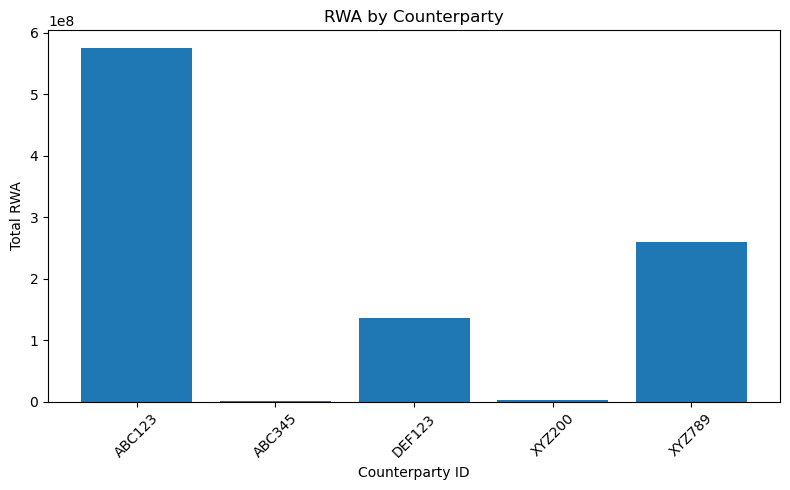

In [343]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    summary_by_counterparty["Counterparty ID"],
    summary_by_counterparty["RWA"]
)

plt.xlabel("Counterparty ID")
plt.ylabel("Total RWA")
plt.title("RWA by Counterparty")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()